## Dataset exploration — seeing the images as tables

Images are just grids of numbers. Here we view the dataset three ways:
metadata (one row per image), the raw pixels of a single image, and
learned feature embeddings (the bridge from pixels to tabular analysis).

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import datasets
from sklearn.manifold import TSNE

import timm
from timm.data import resolve_data_config, create_transform

In [10]:
DATA_DIR   = r"C:\Users\daru1\OneDrive\Desktop\Portfolio\Clothes_Dataset"
MODEL_NAME = "convnext_tiny"
SEED       = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [11]:
base = datasets.ImageFolder(DATA_DIR)           # one subfolder per class
print("classes:", len(base.classes), "| images:", len(base))

classes: 15 | images: 7500


In [12]:
# num_classes=0 -> the model outputs a feature vector instead of class scores
feat_model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=0)
feat_model.eval().to(device)

cfg = resolve_data_config({}, model=feat_model)          # preprocessing the model expects
val_tf = create_transform(**cfg, is_training=False)      # clean, deterministic transform
print("input config:", cfg)

input config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.95, 'crop_mode': 'center'}


In [18]:
rows = []
for path, label in base.samples:              # base.samples = [(filepath, class_index), ...]
    with Image.open(path) as im:
        w, h = im.size
    rows.append({"class": base.classes[label], "width": w, "height": h})

df = pd.DataFrame(rows)
print("shape:", df.shape)
display(df.head())

print("\nimages per class:")
print(df.groupby("class").size())

print("\nimage-size distribution:")
display(df[["width", "height"]].describe())

shape: (7500, 3)


,class,width,height
0,Blazer,720,1280
1,Blazer,720,1280
2,Blazer,720,1280
3,Blazer,720,1280
4,Blazer,720,1280



images per class:
class
Blazer            500
Celana_Panjang    500
Celana_Pendek     500
Gaun              500
Hoodie            500
Jaket             500
Jaket_Denim       500
Jaket_Olahraga    500
Jeans             500
Kaos              500
Kemeja            500
Mantel            500
Polo              500
Rok               500
Sweter            500
dtype: int64

image-size distribution:


,width,height
count,7500.0,7500.0
mean,720.0,1280.0
std,0.0,0.0
min,720.0,1280.0
25%,720.0,1280.0
50%,720.0,1280.0
75%,720.0,1280.0
max,720.0,1280.0


In [14]:
img, label = base[0]              # base (no transform) returns a PIL image
arr = np.array(img)               # (H, W, 3), values 0–255
print("class:", base.classes[label], "| array shape:", arr.shape)
print("top-left 5x5 of the RED channel (0–255):")
print(arr[:5, :5, 0])

class: Blazer | array shape: (1280, 720, 3)
top-left 5x5 of the RED channel (0–255):
[[65 64 62 62 65]
 [65 64 62 62 65]
 [65 64 62 62 65]
 [65 64 62 62 65]
 [66 65 63 62 65]]


In [15]:
x = val_tf(img)                   # tensor [3, 224, 224], normalized floats
print("tensor shape:", tuple(x.shape))
print("red-channel corner (normalized ~ -2..2):")
print(x[0, :5, :5])

tensor shape: (3, 224, 224)
red-channel corner (normalized ~ -2..2):
tensor([[-0.6281, -0.5767, -0.5596, -0.3198, -0.1486],
        [-0.6109, -0.5596, -0.5596, -0.3369, -0.1314],
        [-0.5253, -0.5596, -0.6281, -0.3712, -0.0972],
        [-0.4911, -0.5424, -0.6281, -0.3712, -0.0972],
        [-0.5424, -0.5253, -0.5596, -0.3027, -0.0972]])


In [16]:
vecs, labels = [], []
for path, label in base.samples[::10]:        # every 10th image → ~750-image sample (fast on CPU)
    t = val_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        vecs.append(feat_model(t).squeeze(0).cpu().numpy())
    labels.append(base.classes[label])

emb = pd.DataFrame(vecs)                       # N rows × 768 feature columns
emb["class"] = labels
print("embedding table:", emb.shape)
display(emb.head())

embedding table: (750, 769)


,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,class
0,1.372899,-0.438125,0.797927,-0.299562,0.319699,2.426316,-1.205515,0.967868,0.955453,-1.275431,...,-1.184119,0.503334,-0.727100,-0.538824,-2.584736,-1.034323,-0.265838,1.221032,0.264096,Blazer
1,2.187110,2.636351,1.738745,-0.207840,-0.030623,1.517263,0.397418,2.242670,0.407976,-0.759908,...,-0.219379,-0.893262,1.219822,0.281529,-0.478191,-0.338840,-0.648910,-0.228109,0.594785,Blazer
2,0.755122,2.159160,0.358199,-1.219953,0.231609,1.893770,1.900242,1.904170,1.508267,0.099423,...,0.051177,-1.742634,-0.172339,-1.060808,-0.251857,0.928063,2.344929,-0.016237,1.170868,Blazer
3,0.292986,0.944701,0.164572,-0.866866,-0.351021,0.943748,-0.197035,2.001417,1.120530,-1.026881,...,-0.736967,-3.041950,3.413564,1.214992,0.743759,1.463207,2.294043,1.738326,-0.064867,Blazer
4,1.276356,1.484903,0.892148,-0.674471,-0.208702,1.604764,0.429836,1.830348,0.875077,-1.079978,...,0.334612,-1.285750,1.910366,1.557616,0.833760,-0.402432,-1.551631,0.726485,0.009247,Blazer


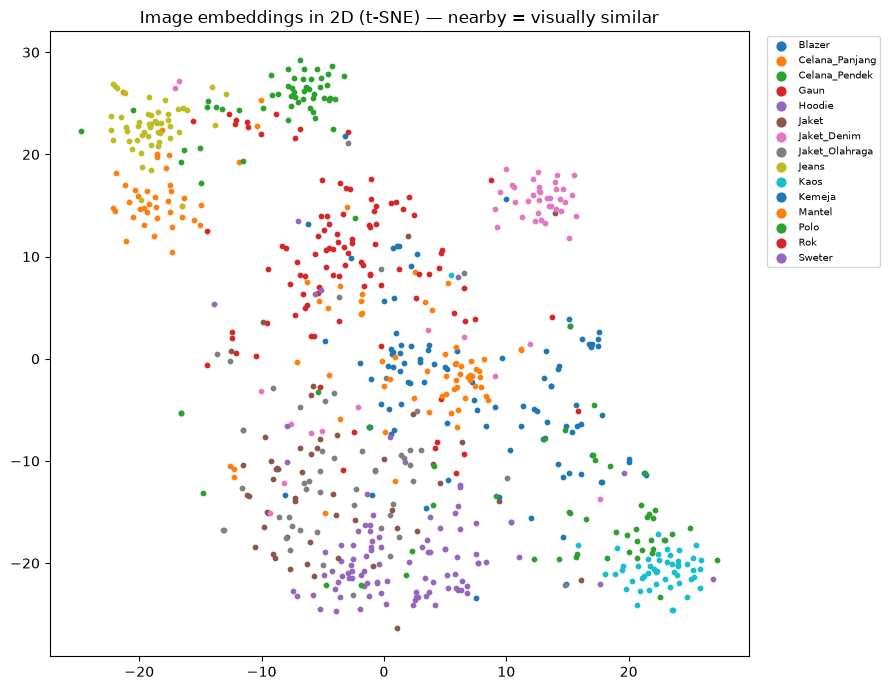

In [17]:
xy = TSNE(n_components=2, init="pca", random_state=SEED).fit_transform(
    emb.drop(columns="class").values
)

plt.figure(figsize=(9, 7))
for cls in sorted(set(labels)):
    m = np.array(labels) == cls
    plt.scatter(xy[m, 0], xy[m, 1], s=10, label=cls)
plt.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Image embeddings in 2D (t-SNE) — nearby = visually similar")
plt.tight_layout()
plt.show()